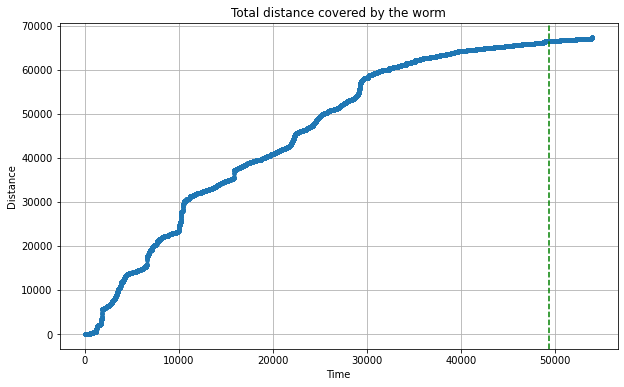

Int64Index([49359], dtype='int64') 324.4222222222222


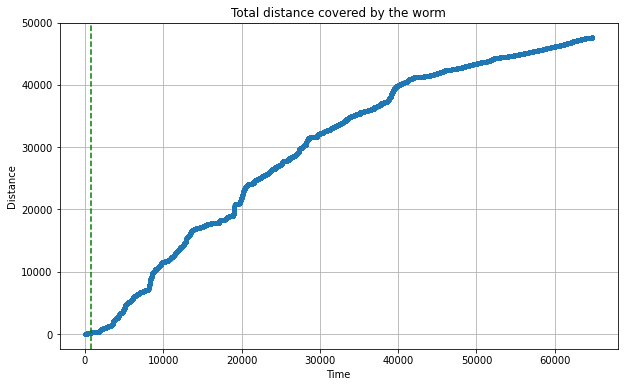

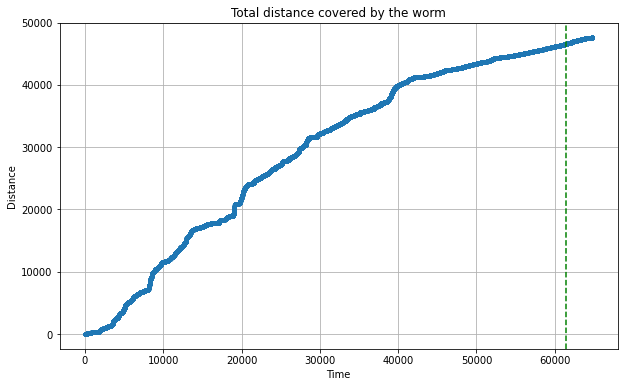

61500 408.1672222222222


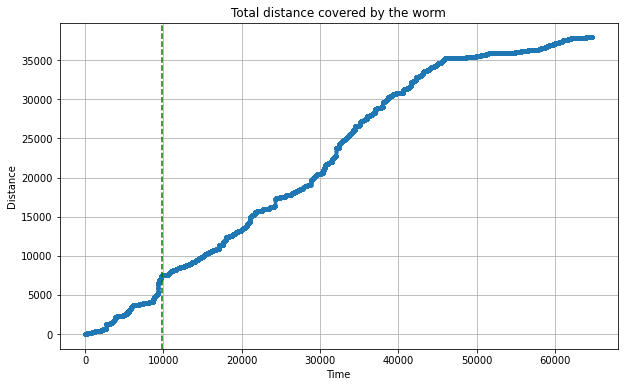

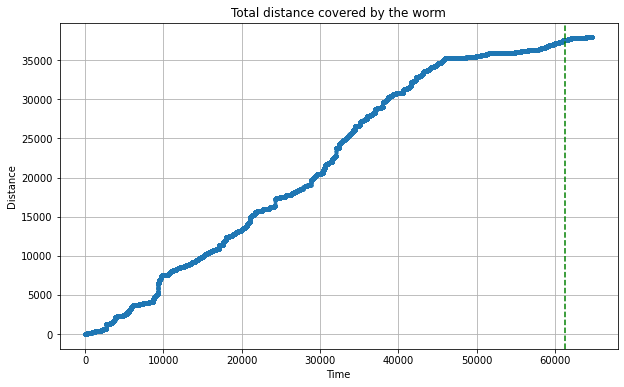

61300 408.05611111111114


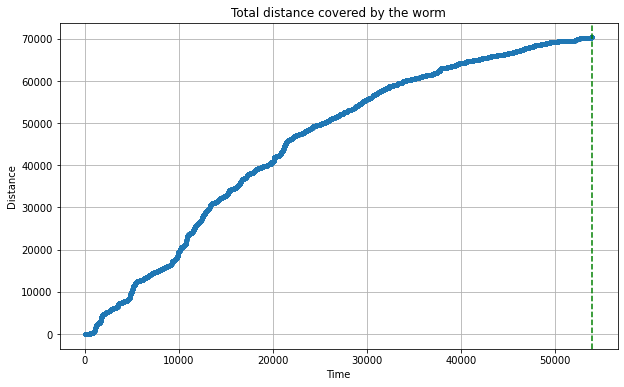

Int64Index([53994], dtype='int64') 354.4972222222222


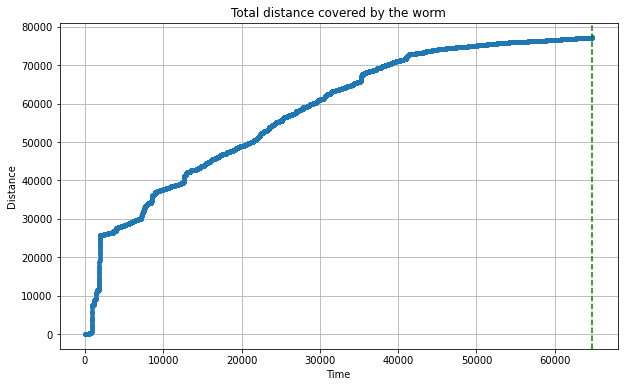

Int64Index([64793], dtype='int64') 426.49666666666667


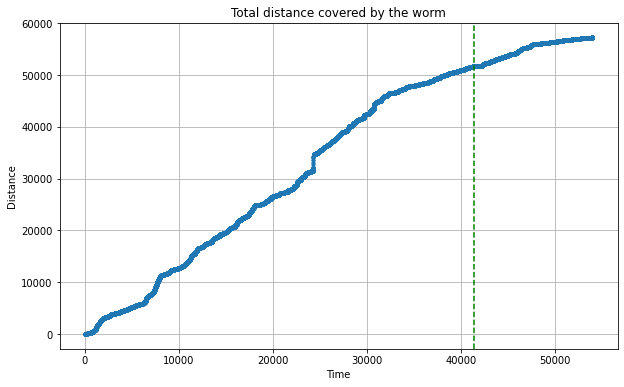

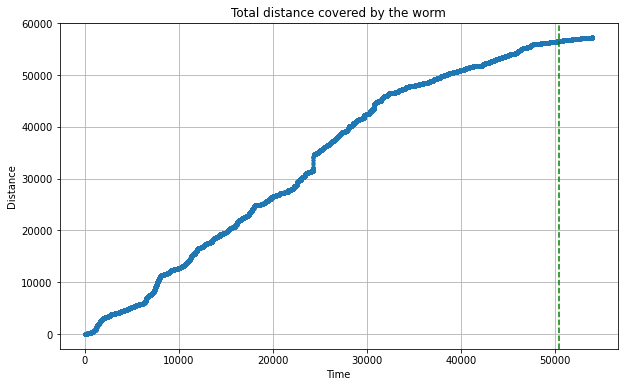

50500 336.05611111111114


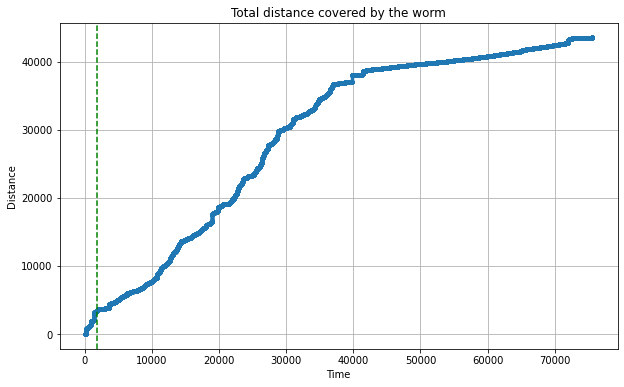

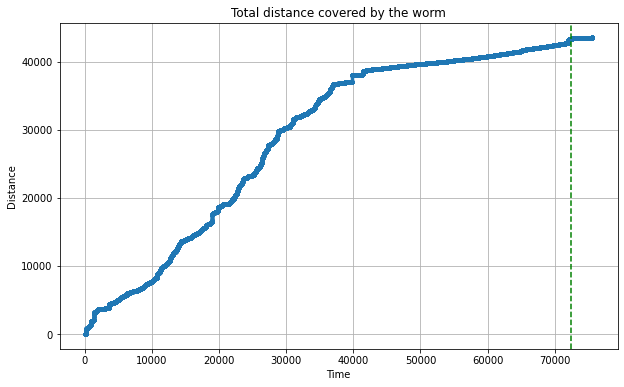

72500 480.2783333333333


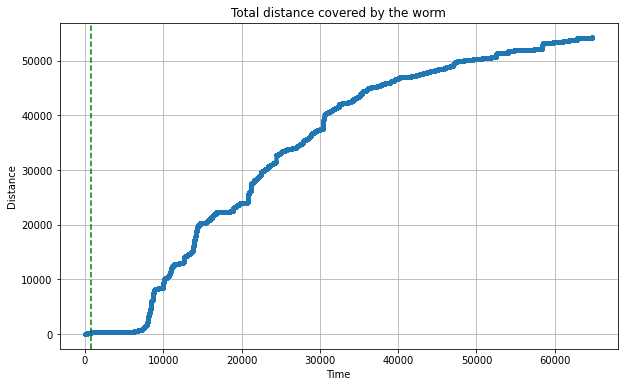

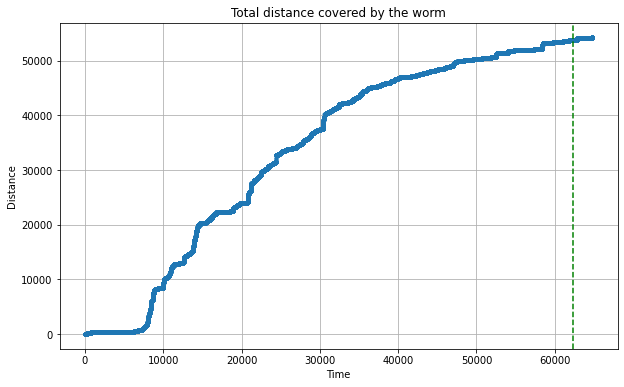

62400 414.1672222222222


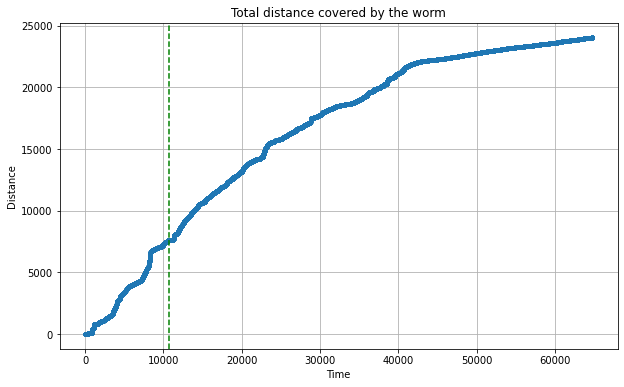

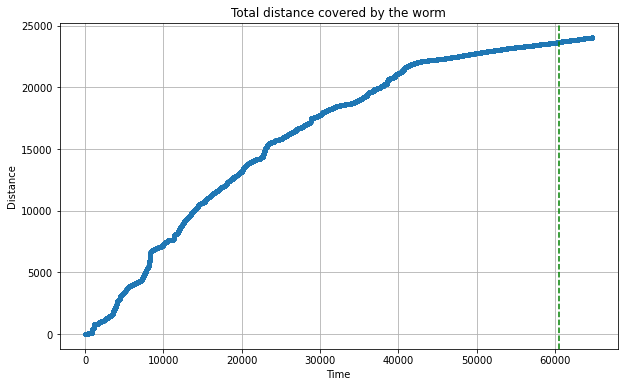

60500 402.1116666666667


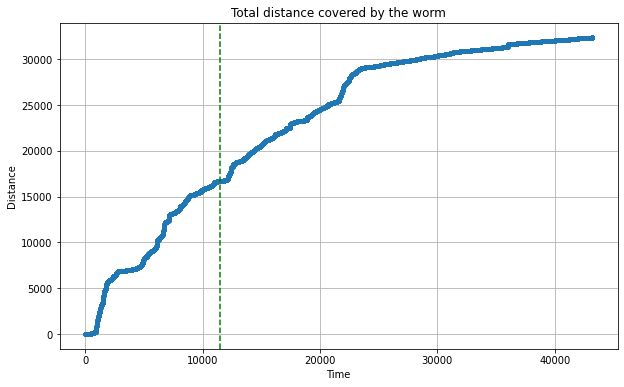

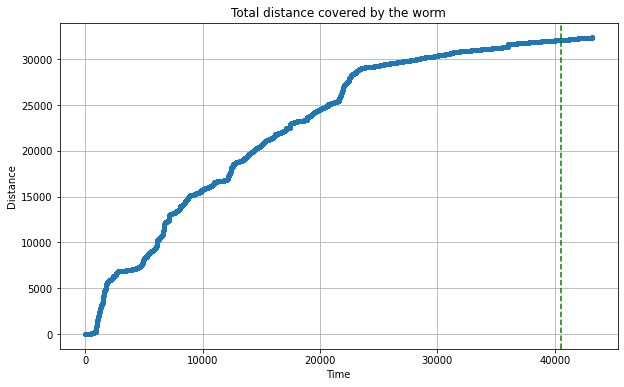

40500 270.00055555555554


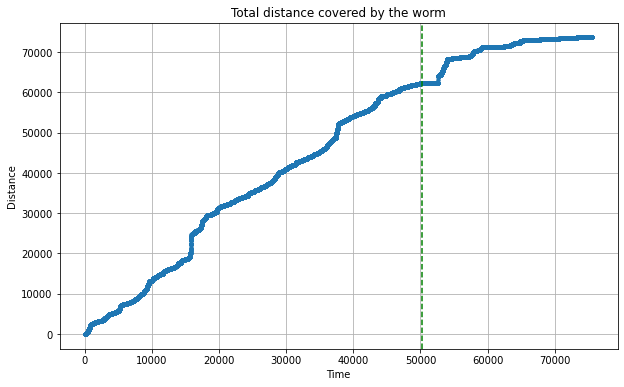

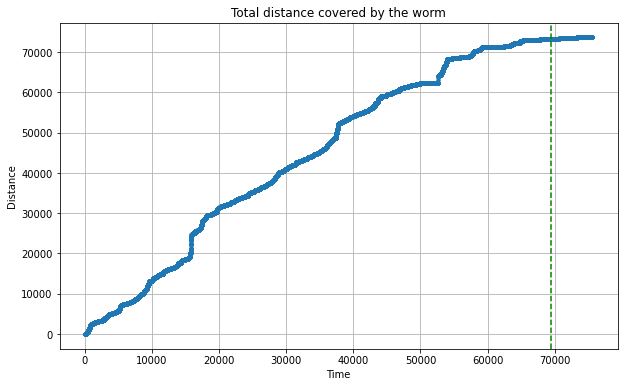

69500 462.1116666666667


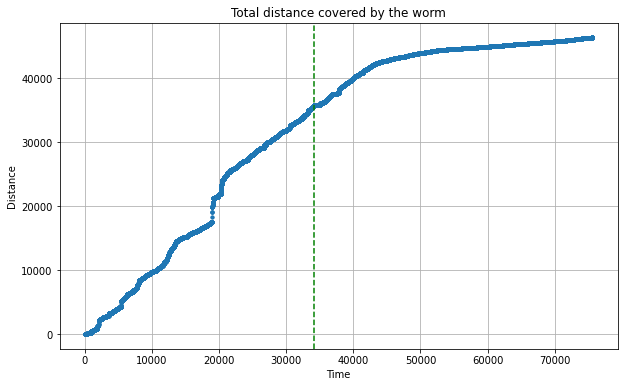

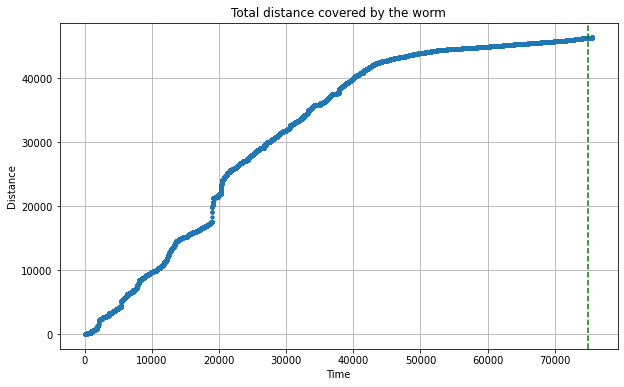

75000 498.1672222222222


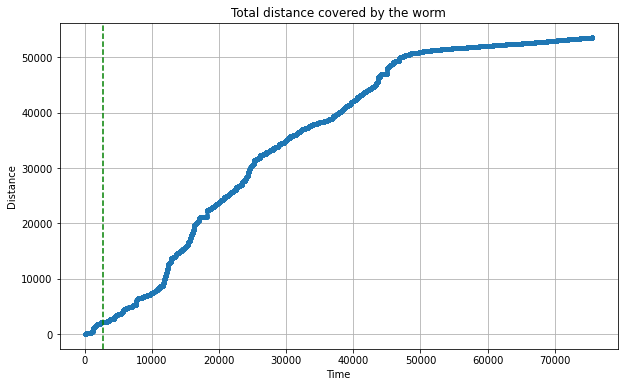

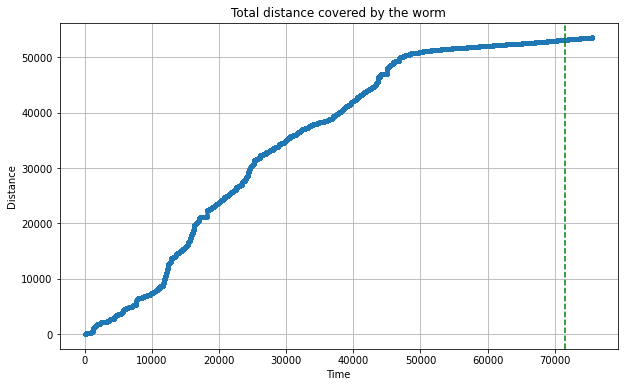

71500 474.22277777777776


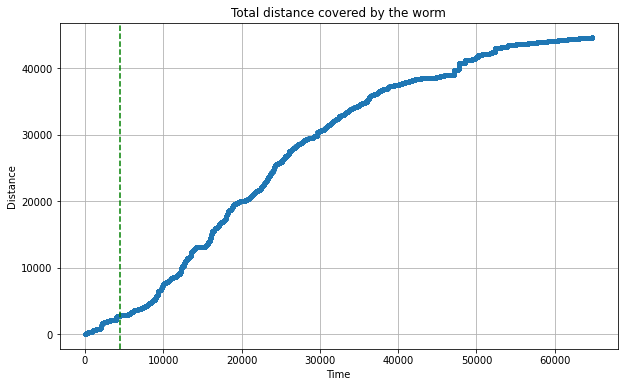

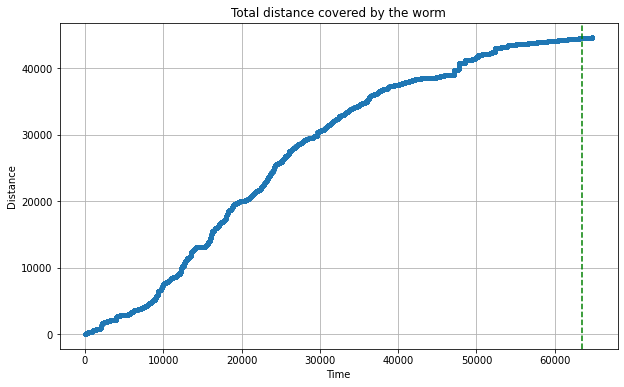

63500 420.2783333333333


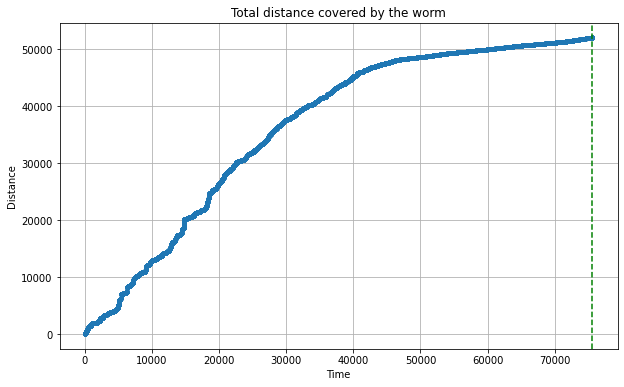

Int64Index([75592], dtype='int64') 498.49611111111113


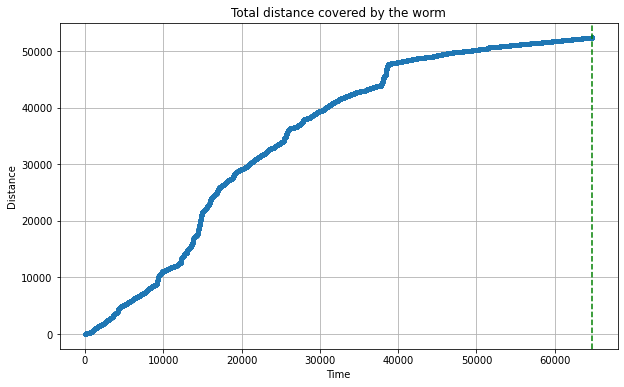

Int64Index([64793], dtype='int64') 426.49666666666667


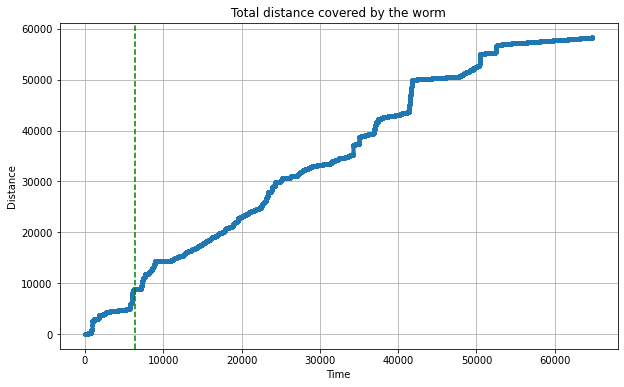

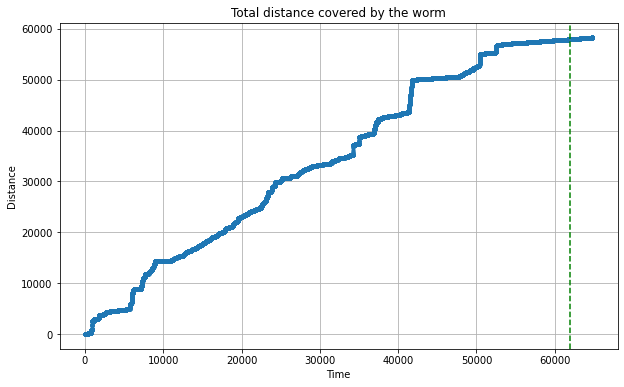

62000 408.445


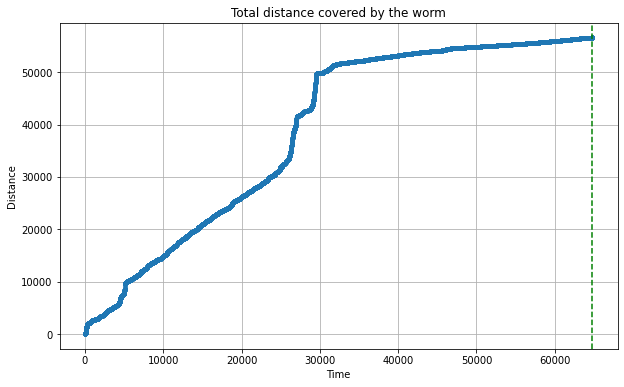

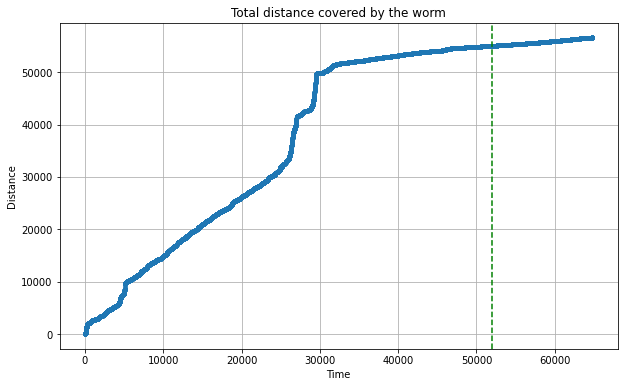

52000 342.38944444444445


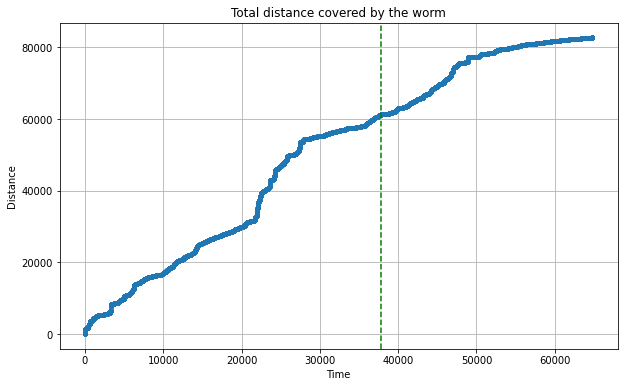

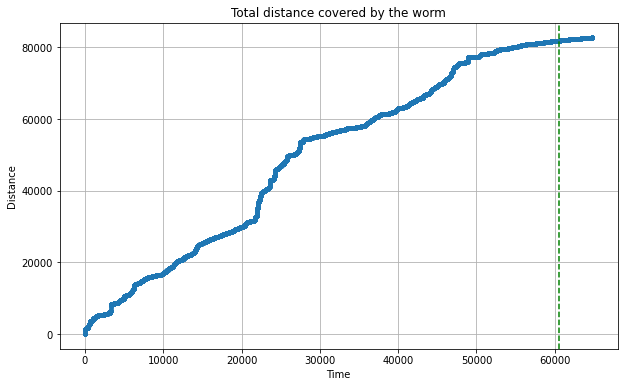

60500 402.1116666666667


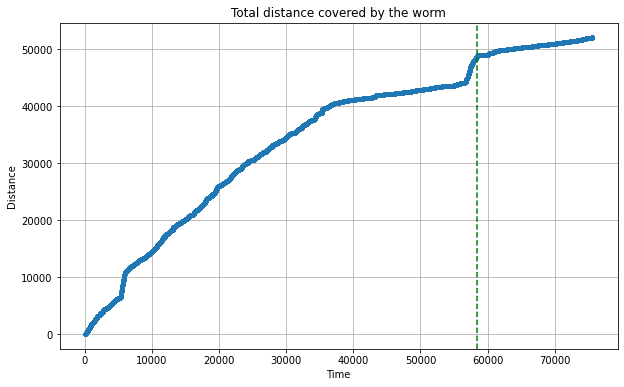

Int64Index([58452], dtype='int64') 384.4738888888889


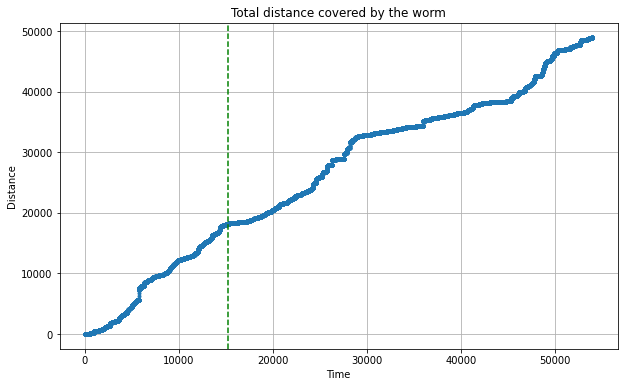

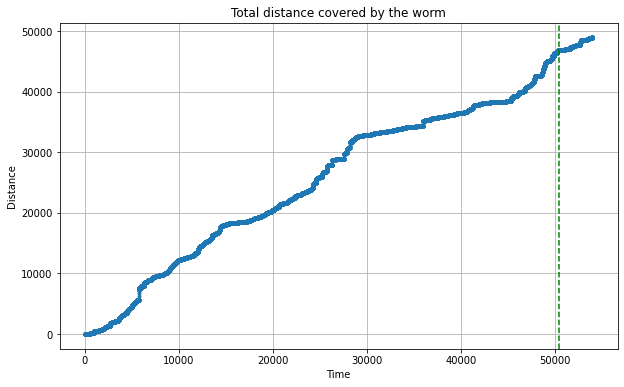

50500 336.05611111111114


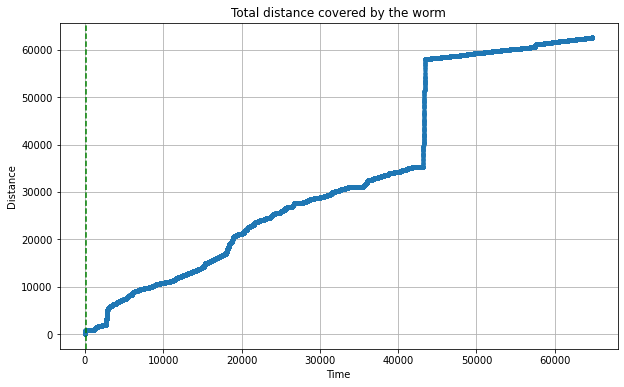

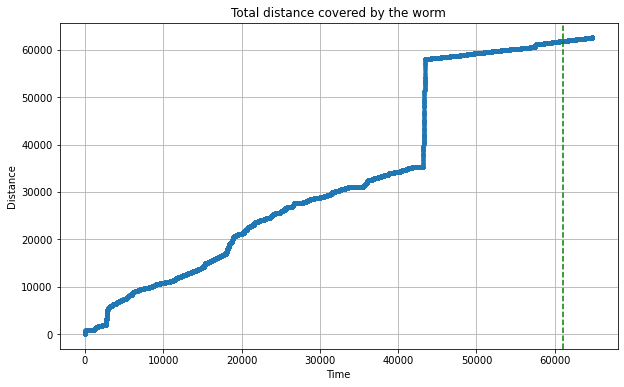

61000 402.38944444444445


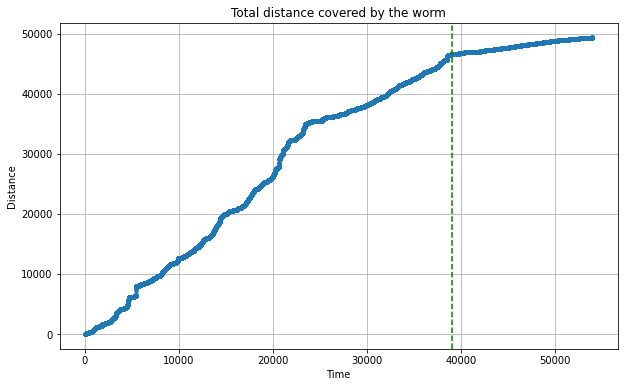

Int64Index([39083], dtype='int64') 258.2133333333333


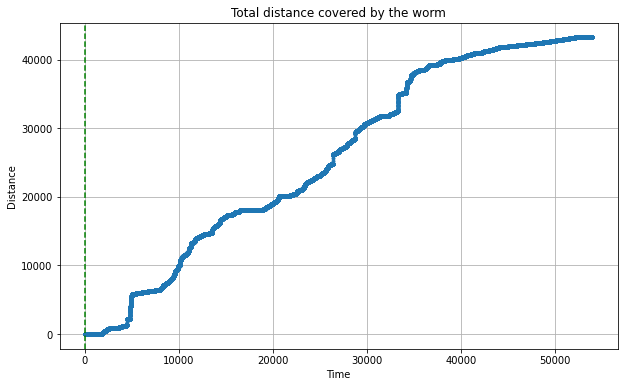

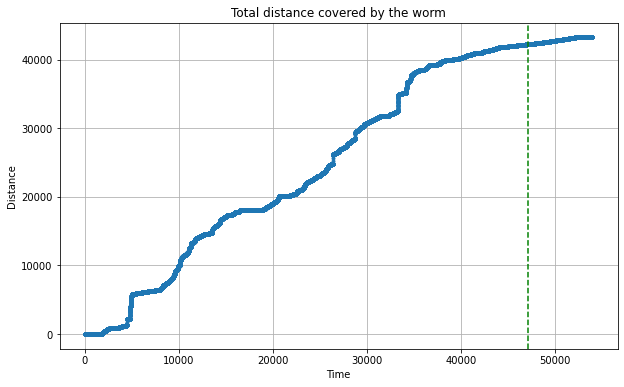

47200 312.22277777777776


,group,average_speed,average_distance_per_frame,maximal_distance_traveled,average_change_in_pixels,average_angular_speed,distance_travaled,distance_travaled,average_change_speed,time_elapsed_(hours),std_speed,std/mean,roaming_fraction,lifespan,drugged,worm_id
0,0.0,0.159337,0.318674,286.482149,-0.044494,0.975632,286.482149,286.482149,0.218700,0.500000,0.409260,2.568519,0.000000,324.422222,0,13
1,1.0,1.898199,3.796399,3747.954292,0.111235,1.465739,3747.954292,3461.472143,2.285841,6.500000,8.573613,4.516709,0.610679,324.422222,0,13
2,2.0,1.557503,3.115005,6639.227846,-0.090100,1.495522,6639.227846,2891.273555,2.150114,12.500000,11.990753,7.698705,0.180200,324.422222,0,13
3,3.0,2.005159,4.010318,10271.038328,0.080089,1.354432,10271.038328,3631.810482,1.615287,18.500000,7.859730,3.919754,0.724138,324.422222,0,13
4,4.0,1.715992,3.431984,13430.232101,-0.102336,1.425293,13430.232101,3159.193773,1.736799,24.500000,7.634931,4.449282,0.525028,324.422222,0,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1679,53.0,0.095324,0.190649,47986.362291,0.011123,1.001846,47986.362291,171.393182,0.077710,318.500000,0.145546,1.526852,0.000000,312.222778,2,36
1680,54.0,0.092102,0.184204,48152.235448,0.000000,0.901730,48152.235448,165.873157,0.076301,324.500000,0.135320,1.469238,0.000000,312.222778,2,36
1681,55.0,0.108652,0.217304,48347.929347,-0.014461,1.106726,48347.929347,195.693899,0.090911,330.500000,0.176447,1.623962,0.000000,312.222778,2,36
1682,56.0,0.111052,0.222103,48547.600360,-0.001112,0.976073,48547.600360,199.671013,0.097382,336.500000,0.191765,1.726811,0.000000,312.222778,2,36


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifespan_functions import wormstats

def adjust_lifespan(lifespan, csv_file_path):
    data = pd.read_csv(csv_file_path)
    n = data.index + 1
    data['Time elapsed (in sec)'] = 2 * n + np.floor((n - 1) / 900) * 5.5 * 3600
    data['Time elapsed (in hours)'] = data['Time elapsed (in sec)']/3600
    lifespan = data[data['Time elapsed (in hours)'] == lifespan].index

    decide = 'Y'
    while decide in ('Y', 'y'):
        # plt.figure(figsize=(10, 6))
        # plt.plot(data.index, data['Changed Pixels'], marker='.', linestyle='')
        # plt.title("Change in pixels as a function of time")
        # plt.xlabel("Time")
        # plt.ylabel("Change in pixels")
        # plt.axhline(y=data['Changed Pixels'].mean(), color='red', linestyle='--', label='Mean of changed pixels')
        # plt.axvline(x=lifespan, color='green', linestyle='--' )
        # plt.grid(True)
        # plt.legend()
        # plt.show()
    
        # plt.figure(figsize=(10, 6))
        # plt.plot(data.loc[data.Speed<100].index, data.loc[data.Speed<100]['Speed'], marker='.', linestyle='')
        # plt.title("Change in speed as a function of time")
        # plt.xlabel("Time")
        # plt.ylabel("Speed")
        # plt.axhline(y=data['Speed'].mean(), color='red', linestyle='--', label='Mean of changed pixels')
        # plt.axvline(x=lifespan, color='green', linestyle='--' )
        # plt.grid(True)
        # plt.legend()
        # plt.show()
    
        data['Instantaneous Distance'] = np.sqrt(
            (data['X'].diff() ** 2) + (data['Y'].diff() ** 2)
        ).fillna(0)
        data['Total Distance'] = data['Instantaneous Distance'].cumsum()
        plt.figure(figsize=(10, 6))
        plt.plot(data.index, data['Total Distance'], marker='.', linestyle='')
        plt.title("Total distance covered by the worm")
        plt.xlabel("Time")
        plt.ylabel("Distance")
        plt.axvline(x=lifespan, color='green', linestyle='--' )
        plt.grid(True)
        plt.show()

        decide = input('Do you want to manually fix lifespan? Y/N')
        if decide not in ('Y', 'y', 'N', 'n'):
            decide = input('Do you want to manually fix lifespan? Y/N')
        elif decide in ('Y', 'y'):
            while True:
                try:
                    new_idx = int(input(f'Enter new index (0 to {len(data) - 1}): ').strip())
                    if 0 <= new_idx < len(data):
                        lifespan = new_idx
                        break
                    else:
                        print(f"Index out of bounds! Please enter a number between 0 and {len(data) - 1}.")
                except ValueError:
                    print("Invalid input! Please enter an integer.")
        elif decide in ('N', 'n'):
            if isinstance(lifespan, pd.Int64Index):  # If lifespan is an Int64Index
                lifespan_idx = lifespan[0]  # Extract the scalar index
            else:
                lifespan_idx = lifespan  # If lifespan is already an integer
            print(lifespan, data['Time elapsed (in hours)'].iloc[lifespan_idx])
            return data['Time elapsed (in hours)'].iloc[lifespan_idx]
        else:
            decide == 'Y'
    # return data['Time elapsed (in hours)'].iloc[lifespan]
    
all_data = []

# for x in range(1, 13):
#     csv_file_path = f'../Lifespan2/companyDrug/companyDrug{x}.csv'  
#     y = wormstats(csv_file_path) 
#     lifespan = y.loc[0,'lifespan']
#     y['lifespan']= adjust_lifespan(lifespan, csv_file_path)
#     y['drugged'] = 1            
#     y['worm_id'] = x             
#     all_data.append(y)           

for x in range(1, 13):
    csv_file_path = f'../Lifespan2/controlTerbinafin/controlTerbinafin{x}.csv' 
    y = wormstats(csv_file_path) 
    lifespan = y.loc[0,'lifespan']
    y['lifespan']= adjust_lifespan(lifespan, csv_file_path)
    y['drugged'] = 0            
    y['worm_id'] = x+12            
    all_data.append(y)       

for x in range(1, 13):
    csv_file_path = f'../Lifespan2/Terbinafin/Terbinafin{x}.csv' 
    y = wormstats(csv_file_path) 
    lifespan = y.loc[0,'lifespan']
    y['lifespan']= adjust_lifespan(lifespan, csv_file_path)
    y['drugged'] = 2            
    y['worm_id'] = x+24             
    all_data.append(y)   

# for x in range(1, 13):
#     csv_file_path = f'../Lifespan2/control/control{x}.csv'  
#     y = wormstats(csv_file_path)  
#     lifespan = y.loc[0,'lifespan']
#     y['lifespan']= adjust_lifespan(lifespan, csv_file_path)
#     y['drugged'] = 0            
#     y['worm_id'] = x+36          
#     all_data.append(y)        

merged_df = pd.concat(all_data, axis=0, ignore_index=True)
merged_df

In [4]:
merged_df.to_csv('../lifespan_merged_datasets/mergedworms_terbinafin.csv')

In [ ]:
import matplotlib as plt

plt.figure(figsize=(10, 6))
plt.plot(merged_df, data['Changed Pixels'], marker='.', linestyle='')
plt.title("Change in pixels as a function of time")
plt.xlabel("Time")
plt.ylabel("Change in pixels")
plt.axhline(y=data['Changed Pixels'].mean(), color='red', linestyle='--', label='Mean of changed pixels')
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
# 35000 64750 54200 60500